# LAB 13 & 14: XÂY DỰNG MÔ HÌNH MACHINE LEARNING ĐƠN GIẢN

## Bài toán 1: Dự đoán doanh thu

### Mục tiêu

Trong bài thực hành này, chúng ta sẽ xây dựng một mô hình Machine Learning đơn giản để **dự đoán doanh thu hàng ngày** dựa trên dữ liệu lịch sử.

Dữ liệu gồm các thông tin:

- `date`: ngày
- `orders`: số lượng đơn hàng trong ngày
- `revenue_trieu`: doanh thu trong ngày, đơn vị triệu đồng

### Nội dung thực hành

Notebook gồm các bước:

1. Đọc và khám phá dữ liệu
2. Tiền xử lý dữ liệu
3. Phân tích dữ liệu và trực quan hóa
4. Xây dựng các đặc trưng (features)
5. Chia dữ liệu thành tập Train/Test
6. Xây dựng mô hình Machine Learning
7. Đánh giá mô hình
8. So sánh doanh thu thực tế và doanh thu dự đoán
9. Thực hiện dự đoán doanh thu cho ngày mới

### Bài toán Machine Learning

Đây là bài toán **Regression (hồi quy)** vì biến mục tiêu `revenue_trieu` là một giá trị số liên tục.

Ta xây dựng mô hình:

$$
\hat{y} = f(X)
$$

Trong đó:

- $X$: các đặc trưng đầu vào
- $y$: doanh thu thực tế
- $\hat{y}$: doanh thu được mô hình dự đoán

### 1. Import các thư viện

Sử dụng các thư viện:

- `pandas`: xử lý dữ liệu
- `numpy`: tính toán số học
- `matplotlib`: trực quan hóa dữ liệu
- `scikit-learn`: xây dựng và đánh giá mô hình Machine Learning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

RAW = Path("../data/raw"); RAW.mkdir(parents=True, exist_ok=True)
PROCESSED = Path("../data/processed"); PROCESSED.mkdir(parents=True, exist_ok=True)
print("pandas", pd.__version__, "| numpy", np.__version__)

pandas 3.0.5 | numpy 2.5.2


### 2. Đọc dữ liệu

Đọc file `market_demand.csv` bằng Pandas.

Sau khi đọc dữ liệu, chúng ta kiểm tra:

- Kích thước dữ liệu
- Tên các cột
- Một số dòng đầu tiên
- Kiểu dữ liệu của từng cột

In [2]:
# Đọc dữ liệu
df = pd.read_csv(RAW / "market_demand.csv")

# Hiển thị kích thước dữ liệu
print("Kích thước dữ liệu:", df.shape)

# Hiển thị 5 dòng đầu tiên
df.head()

# Kiểm tra kiểu dữ liệu
print("\nKiểu dữ liệu:")
print(df.dtypes)

Kích thước dữ liệu: (1096, 3)

Kiểu dữ liệu:
date                 str
orders             int64
revenue_trieu    float64
dtype: object


### 3. Kiểm tra chất lượng dữ liệu

Trước khi xây dựng mô hình, cần kiểm tra:

- Giá trị thiếu (missing values)
- Dữ liệu trùng lặp
- Các giá trị bất thường
- Thống kê mô tả của dữ liệu

In [3]:
# Kiểm tra giá trị thiếu
print("Số lượng giá trị thiếu:")
print(df.isnull().sum())

# Kiểm tra số dòng trùng lặp
print("\nSố dòng trùng lặp:", df.duplicated().sum())

# Thống kê mô tả
print("\nThống kê mô tả:")
df.describe()

Số lượng giá trị thiếu:
date             0
orders           0
revenue_trieu    0
dtype: int64

Số dòng trùng lặp: 0

Thống kê mô tả:


,orders,revenue_trieu
count,1096.000000,1096.000000
mean,1086.013686,572.650000
std,133.061996,68.986466
min,740.000000,395.900000
25%,987.000000,523.350000
50%,1083.000000,570.750000
75%,1177.250000,619.725000
max,1594.000000,810.900000


### 4. Xử lý biến thời gian

Cột `date` hiện đang ở dạng chuỗi (`object`).

Chúng ta chuyển đổi sang kiểu `datetime` để có thể trích xuất các đặc trưng thời gian như:

- Năm
- Tháng
- Ngày
- Ngày trong tuần

Các đặc trưng này có thể giúp mô hình nhận biết được **quy luật theo thời gian** của doanh thu.

In [4]:
# Chuyển date sang datetime
df["date"] = pd.to_datetime(df["date"])

# Sắp xếp dữ liệu theo thời gian
df = df.sort_values("date").reset_index(drop=True)

# Tạo các đặc trưng thời gian
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_of_week"] = df["date"].dt.dayofweek

# Hiển thị dữ liệu
df.head()

,date,orders,revenue_trieu,year,month,day,day_of_week
0,2023-01-01,1049,567.3,2023,1,1,6
1,2023-01-02,871,461.6,2023,1,2,0
2,2023-01-03,957,502.3,2023,1,3,1
3,2023-01-04,990,520.1,2023,1,4,2
4,2023-01-05,938,478.5,2023,1,5,3


### 5. Phân tích và trực quan hóa doanh thu

Trước khi xây dựng mô hình, chúng ta quan sát sự thay đổi của doanh thu theo thời gian.

Biểu đồ đường giúp trả lời các câu hỏi:

- Doanh thu có xu hướng tăng hay giảm?
- Doanh thu có biến động mạnh không?
- Có những thời điểm doanh thu cao hoặc thấp bất thường không?

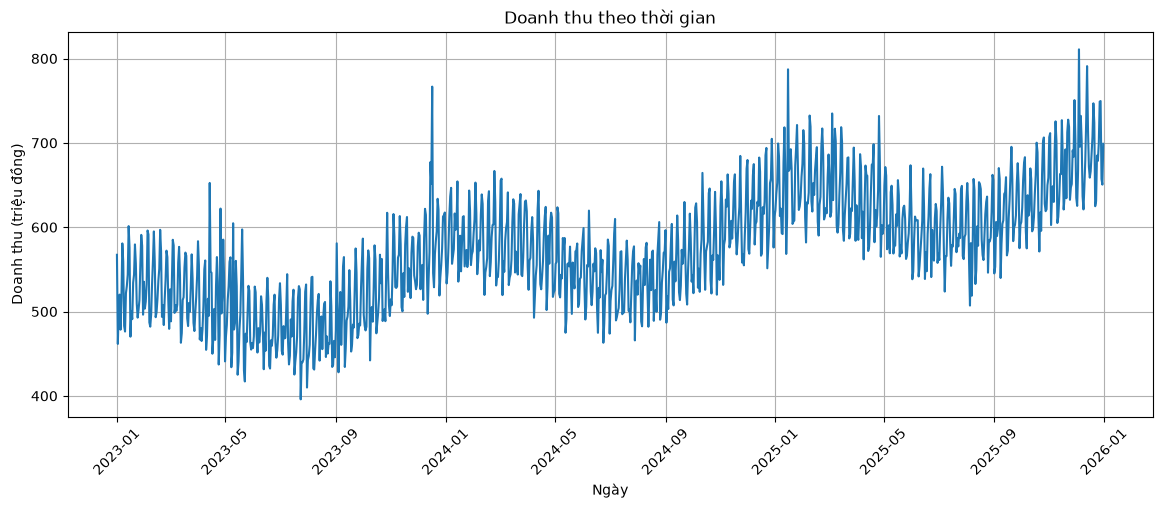

In [5]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["revenue_trieu"]
)

plt.title("Doanh thu theo thời gian")
plt.xlabel("Ngày")
plt.ylabel("Doanh thu (triệu đồng)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### 6. Mối quan hệ giữa số đơn hàng và doanh thu

Một giả định hợp lý là số lượng đơn hàng có thể ảnh hưởng đến doanh thu.

Ta sử dụng biểu đồ scatter để quan sát mối quan hệ giữa:

- `orders`: số lượng đơn hàng
- `revenue_trieu`: doanh thu

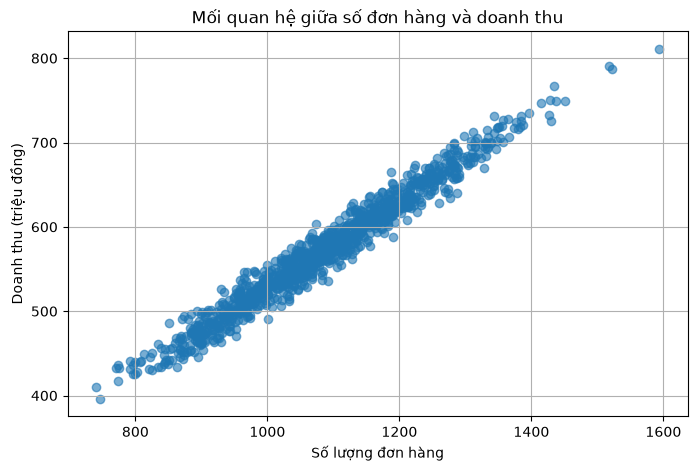

In [6]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["orders"],
    df["revenue_trieu"],
    alpha=0.6
)

plt.title("Mối quan hệ giữa số đơn hàng và doanh thu")
plt.xlabel("Số lượng đơn hàng")
plt.ylabel("Doanh thu (triệu đồng)")
plt.grid(True)

plt.show()

### 7. Xây dựng các đặc trưng

Ta sử dụng các biến sau làm đầu vào cho mô hình:

#### Đặc trưng thời gian

- `year`
- `month`
- `day`
- `day_of_week`

#### Đặc trưng kinh doanh

- `orders`

Mục tiêu cần dự đoán:

- `revenue_trieu`

Do đó:

$$
X = [orders, year, month, day, day\_of\_week]
$$

$$
y = revenue\_trieu
$$

In [7]:
# Các biến đầu vào
features = [
    "orders",
    "year",
    "month",
    "day",
    "day_of_week"
]

X = df[features]
y = df["revenue_trieu"]

print("Các features:")
print(features)

print("\nKích thước X:", X.shape)
print("Kích thước y:", y.shape)

Các features:
['orders', 'year', 'month', 'day', 'day_of_week']

Kích thước X: (1096, 5)
Kích thước y: (1096,)


### 8. Chia dữ liệu thành Train và Test

Vì dữ liệu có tính chất **chuỗi thời gian**, chúng ta không nên chia dữ liệu ngẫu nhiên.

Thay vào đó:

- **80% dữ liệu đầu tiên** → Train
- **20% dữ liệu cuối cùng** → Test

Cách chia này mô phỏng tình huống thực tế:

> Sử dụng dữ liệu quá khứ để xây dựng mô hình và sử dụng dữ liệu tương lai để kiểm tra khả năng dự đoán.

Đây là cách chia phù hợp hơn cho bài toán dự báo doanh thu theo thời gian.

In [8]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Train:", X_train.shape)
print("Test :", X_test.shape)

print("\nThời gian Train:")
print(df["date"].iloc[0], "->", df["date"].iloc[split_index - 1])

print("\nThời gian Test:")
print(df["date"].iloc[split_index], "->", df["date"].iloc[-1])

Train: (876, 5)
Test : (220, 5)

Thời gian Train:
2023-01-01 00:00:00 -> 2025-05-25 00:00:00

Thời gian Test:
2025-05-26 00:00:00 -> 2025-12-31 00:00:00


### 9. Xây dựng mô hình Linear Regression

Trong bài lab đầu tiên, chúng ta sử dụng **Linear Regression** vì đây là một mô hình hồi quy đơn giản và dễ giải thích.

Mô hình giả định rằng doanh thu có thể được biểu diễn dưới dạng:

$$
\hat{y}
=
\beta_0
+
\beta_1x_1
+
\beta_2x_2
+
...
+
\beta_nx_n
$$

Trong đó:

- $\hat{y}$: doanh thu dự đoán
- $\beta_0$: intercept
- $\beta_i$: hệ số của feature
- $x_i$: giá trị của feature

Mục tiêu của mô hình là tìm các hệ số sao cho dự đoán gần với doanh thu thực tế nhất.

In [9]:
# Khởi tạo mô hình
model = LinearRegression()

# Huấn luyện mô hình
model.fit(X_train, y_train)

print("Huấn luyện mô hình hoàn tất!")

Huấn luyện mô hình hoàn tất!


### 10. Phân tích hệ số của mô hình

Các hệ số của Linear Regression cho biết mức độ và chiều hướng tác động của từng feature lên doanh thu dự đoán.

Lưu ý:

> Hệ số lớn không nhất thiết có nghĩa feature đó quan trọng nhất nếu các feature có thang đo khác nhau.

In [10]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

display(coefficients)

print("Intercept:", model.intercept_)

,Feature,Coefficient
0,orders,0.462972
1,year,8.574590
2,month,-0.034594
3,day,0.029702
4,day_of_week,1.942938


Intercept: -17290.430395925043


### 11. Dự đoán doanh thu

Sau khi mô hình được huấn luyện trên tập Train, chúng ta sử dụng mô hình để dự đoán doanh thu của tập Test.

In [11]:
# Dự đoán
y_pred = model.predict(X_test)

# Tạo bảng so sánh
result = pd.DataFrame({
    "date": df["date"].iloc[split_index:].values,
    "actual_revenue": y_test.values,
    "predicted_revenue": y_pred
})

display(result.head(10))

,date,actual_revenue,predicted_revenue
0,2025-05-26,562.4,558.908538
1,2025-05-27,566.2,558.103347
2,2025-05-28,581.8,593.872939
3,2025-05-29,592.7,607.419877
4,2025-05-30,622.8,632.078143
5,2025-05-31,673.4,687.292556
6,2025-06-01,621.9,632.753211
7,2025-06-02,538.3,551.216519
8,2025-06-03,547.3,559.670767
9,2025-06-04,585.8,591.273611


### 12. Đánh giá mô hình

Sử dụng ba metric phổ biến cho bài toán Regression:

### MAE – Mean Absolute Error

$$
MAE =
\frac{1}{n}
\sum_{i=1}^{n}
|y_i-\hat{y}_i|
$$

MAE cho biết trung bình mô hình dự đoán sai bao nhiêu đơn vị doanh thu.

---

### RMSE – Root Mean Squared Error

$$
RMSE =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}
$$

RMSE phạt mạnh hơn đối với những lỗi dự đoán lớn.

---

### R² – Coefficient of Determination

$$
R^2 =
1 -
\frac{
\sum(y_i-\hat{y}_i)^2
}{
\sum(y_i-\bar{y})^2
}
$$

R² càng gần 1 thì mô hình giải thích được càng nhiều biến động của biến mục tiêu.

In [12]:
# Tính các metric
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("-" * 35)
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
-----------------------------------
MAE  : 10.1017
MSE  : 157.5023
RMSE : 12.5500
R²   : 0.9459


### 13. So sánh doanh thu thực tế và dự đoán

Biểu đồ dưới đây giúp trực quan hóa khả năng dự đoán của mô hình.

- Đường thứ nhất: doanh thu thực tế
- Đường thứ hai: doanh thu dự đoán

Nếu hai đường có xu hướng gần nhau, mô hình có khả năng nắm bắt được xu hướng doanh thu.

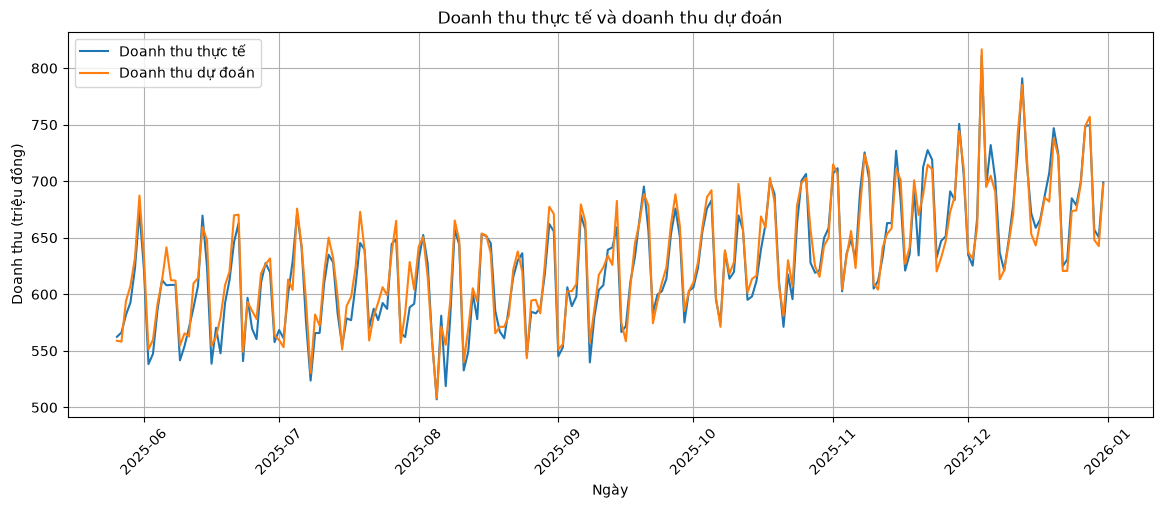

In [13]:
plt.figure(figsize=(14, 5))

plt.plot(
    result["date"],
    result["actual_revenue"],
    label="Doanh thu thực tế"
)

plt.plot(
    result["date"],
    result["predicted_revenue"],
    label="Doanh thu dự đoán"
)

plt.title("Doanh thu thực tế và doanh thu dự đoán")
plt.xlabel("Ngày")
plt.ylabel("Doanh thu (triệu đồng)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### 14. Phân tích sai số dự đoán

Tạo thêm biến `error`:

$$
error = y - \hat{y}
$$

Trong đó:

- `error > 0`: mô hình dự đoán thấp hơn thực tế
- `error < 0`: mô hình dự đoán cao hơn thực tế

In [14]:
result["error"] = (
    result["actual_revenue"]
    - result["predicted_revenue"]
)

display(result.head(10))

,date,actual_revenue,predicted_revenue,error
0,2025-05-26,562.4,558.908538,3.491462
1,2025-05-27,566.2,558.103347,8.096653
2,2025-05-28,581.8,593.872939,-12.072939
3,2025-05-29,592.7,607.419877,-14.719877
4,2025-05-30,622.8,632.078143,-9.278143
5,2025-05-31,673.4,687.292556,-13.892556
6,2025-06-01,621.9,632.753211,-10.853211
7,2025-06-02,538.3,551.216519,-12.916519
8,2025-06-03,547.3,559.670767,-12.370767
9,2025-06-04,585.8,591.273611,-5.473611


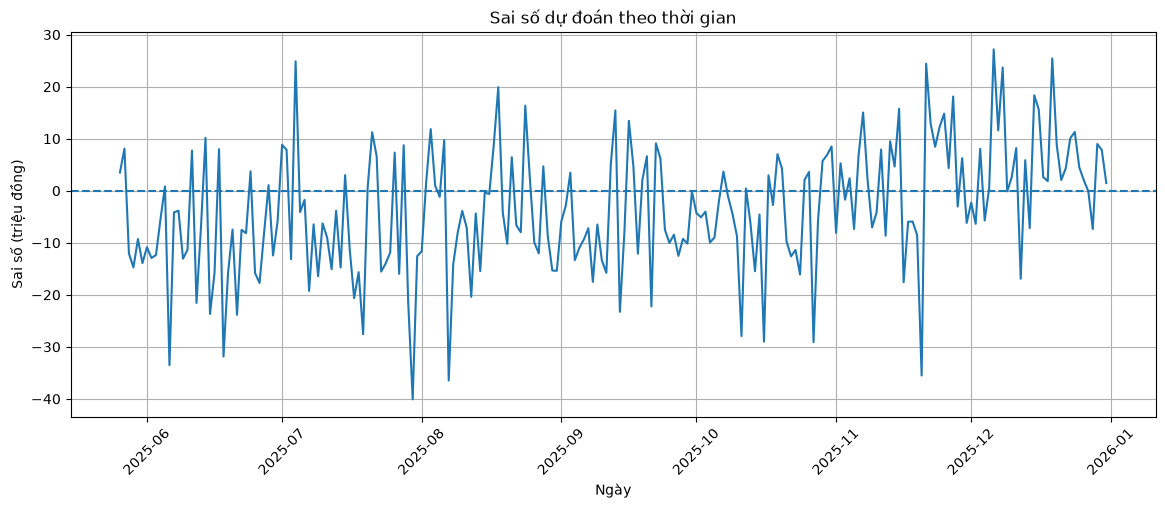

In [15]:
plt.figure(figsize=(14, 5))

plt.plot(
    result["date"],
    result["error"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.title("Sai số dự đoán theo thời gian")
plt.xlabel("Ngày")
plt.ylabel("Sai số (triệu đồng)")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### 15. Dự đoán doanh thu cho một ngày mới

Sau khi mô hình được huấn luyện, chúng ta có thể sử dụng mô hình để dự đoán doanh thu cho một ngày mới.

Ví dụ, giả sử:

- Ngày: `2026-01-01`
- Số đơn hàng dự kiến: `1000`

Ta tạo các đặc trưng tương ứng và đưa vào mô hình.

In [16]:
# Thông tin ngày cần dự đoán
new_date = pd.Timestamp("2026-01-01")
new_orders = 1000

# Tạo feature
new_data = pd.DataFrame({
    "orders": [new_orders],
    "year": [new_date.year],
    "month": [new_date.month],
    "day": [new_date.day],
    "day_of_week": [new_date.dayofweek]
})

# Dự đoán
predicted_revenue = model.predict(new_data)[0]

print(f"Ngày dự đoán: {new_date.date()}")
print(f"Số đơn hàng dự kiến: {new_orders}")
print(f"Doanh thu dự đoán: {predicted_revenue:.2f} triệu đồng")

Ngày dự đoán: 2026-01-01
Số đơn hàng dự kiến: 1000
Doanh thu dự đoán: 550.49 triệu đồng


## 16. Tổng kết

Trong bài thực hành này, chúng ta đã xây dựng một mô hình Machine Learning để dự đoán doanh thu.

#### Các bước đã thực hiện

1. Đọc dữ liệu từ file CSV
2. Kiểm tra dữ liệu thiếu và dữ liệu trùng lặp
3. Chuyển đổi biến ngày tháng
4. Tạo các đặc trưng thời gian
5. Phân tích mối quan hệ giữa số đơn hàng và doanh thu
6. Chia dữ liệu thành Train/Test theo thứ tự thời gian
7. Xây dựng mô hình Linear Regression
8. Dự đoán doanh thu trên tập Test
9. Đánh giá mô hình bằng:
   - MAE
   - MSE
   - RMSE
   - R²
10. Trực quan hóa doanh thu thực tế và doanh thu dự đoán
11. Sử dụng mô hình để dự đoán doanh thu cho ngày mới

#### Kết luận

Bài toán dự đoán doanh thu là một bài toán **Regression**.

Trong bài lab này, Linear Regression được sử dụng làm mô hình cơ sở (baseline). Đây là mô hình đơn giản, dễ triển khai và dễ giải thích.

Trong các bài thực hành nâng cao, có thể thử các mô hình mạnh hơn như:

- Decision Tree
- Random Forest
- Gradient Boosting
- XGBoost
- LightGBM

để so sánh và cải thiện khả năng dự đoán.

## 17. Bài tập thực hành

### Bài tập 1 – Phân tích dữ liệu

1. Doanh thu trung bình mỗi ngày là bao nhiêu?
2. Ngày nào có doanh thu cao nhất?
3. Ngày nào có doanh thu thấp nhất?
4. Số đơn hàng và doanh thu có mối quan hệ như thế nào?

---

### Bài tập 2 – Thử nghiệm Feature Engineering

Bổ sung các đặc trưng mới:

- `day_of_year`
- `week_of_year`
- `is_weekend`

Sau đó huấn luyện lại mô hình và so sánh kết quả.

---

### Bài tập 3 – So sánh mô hình

Thay Linear Regression bằng:

- Decision Tree Regressor
- Random Forest Regressor

So sánh các mô hình bằng:

- MAE
- RMSE
- R²

Mô hình nào cho kết quả tốt nhất?

---

### Bài tập 4 – Phân tích kết quả

Trả lời các câu hỏi:

1. Feature nào có ảnh hưởng lớn nhất đến dự đoán doanh thu?
2. Mô hình có dự đoán tốt các ngày có doanh thu rất cao không?
3. Những trường hợp nào mô hình dự đoán sai nhiều?
4. Nếu muốn cải thiện mô hình, bạn sẽ bổ sung thêm những dữ liệu nào?

---

### Bài tập 5 – Dự đoán

Giả sử ngày tiếp theo có:

- 1.100 đơn hàng
- Ngày là thứ Hai

Hãy sử dụng mô hình đã huấn luyện để dự đoán doanh thu.

# Lab 14: Thực hành xây dựng mô hình học máy cho tập dữ liệu enterprise_transaction_clean

In [17]:
pip install pyarrow

Note: you may need to restart the kernel to use updated packages.


In [18]:
import pandas as pd

# 1. Đường dẫn tới file Parquet đầu vào và file CSV đầu ra nằm cùng trong thư mục PROCESSED
file_parquet = PROCESSED / "enterprise_transactions_clean.parquet"
file_csv = PROCESSED / "enterprise_transactions_clean.csv"

print("Đang đọc file Parquet...")
# 2. Đọc file Parquet vào DataFrame của Pandas
# Pandas sẽ tự động dùng thư viện 'pyarrow' dưới nền để đọc
df = pd.read_parquet(file_parquet)

print(f"Đã đọc xong. File có {df.shape[0]:,} dòng và {df.shape[1]} cột.")

print("Đang xuất sang file CSV...")
# 3. Xuất DataFrame thành file CSV vào cùng thư mục PROCESSED
# index=False để không ghi cột chỉ số (0, 1, 2...) vào file CSV cho sạch dữ liệu
df.to_csv(file_csv, index=False, encoding="utf-8-sig")

print(f"Chuyển đổi thành công! File đã được lưu tại: {file_csv}")

Đang đọc file Parquet...
Đã đọc xong. File có 59,985 dòng và 16 cột.
Đang xuất sang file CSV...
Chuyển đổi thành công! File đã được lưu tại: ..\data\processed\enterprise_transactions_clean.csv


In [19]:
import pandas as pd

# 1. Đường dẫn tới file Parquet đầu vào và file CSV đầu ra nằm cùng trong thư mục PROCESSED
file_parquet = PROCESSED / "feature_matrix.parquet"
file_csv = PROCESSED / "feature_matrix.csv"

print("Đang đọc file Parquet...")
# 2. Đọc file Parquet vào DataFrame của Pandas
# Pandas sẽ tự động dùng thư viện 'pyarrow' dưới nền để đọc
df = pd.read_parquet(file_parquet)

print(f"Đã đọc xong. File có {df.shape[0]:,} dòng và {df.shape[1]} cột.")

print("Đang xuất sang file CSV...")
# 3. Xuất DataFrame thành file CSV vào cùng thư mục PROCESSED
# index=False để không ghi cột chỉ số (0, 1, 2...) vào file CSV cho sạch dữ liệu
df.to_csv(file_csv, index=False, encoding="utf-8-sig")

print(f"Chuyển đổi thành công! File đã được lưu tại: {file_csv}")

Đang đọc file Parquet...
Đã đọc xong. File có 8,000 dòng và 30 cột.
Đang xuất sang file CSV...
Chuyển đổi thành công! File đã được lưu tại: ..\data\processed\feature_matrix.csv


### MACHINE LEARNING TRÊN DỮ LIỆU GIAO DỊCH DOANH NGHIỆP

## Bài toán: Dự đoán doanh thu ngày tiếp theo

Trong bài lab này, chúng ta sử dụng dữ liệu giao dịch của một doanh nghiệp để xây dựng
mô hình Machine Learning dự đoán **tổng doanh thu của ngày tiếp theo**.

Khác với bài lab cơ bản, dữ liệu lần này có:

- Gần 60.000 giao dịch
- Nhiều biến phân loại
- Dữ liệu thời gian
- Thông tin khách hàng
- Thông tin chi nhánh
- Kênh bán hàng
- Danh mục sản phẩm
- Phương thức thanh toán
- Trạng thái giao dịch
- Thông tin fraud
- Các biến đánh dấu dữ liệu đã được xử lý

### Mục tiêu

Xây dựng mô hình:

$$
Revenue_{t+1} = f(X_t, X_{t-1}, X_{t-2}, ...)
$$

Trong đó:

- $t$: ngày hiện tại
- $Revenue_{t+1}$: tổng doanh thu của ngày tiếp theo
- $X_t$: các thông tin có thể biết tại thời điểm $t$

### Nội dung

1. Data Understanding
2. Data Quality
3. Exploratory Data Analysis
4. Xử lý dữ liệu thời gian
5. Tổng hợp dữ liệu giao dịch theo ngày
6. Feature Engineering
7. Phát hiện và tránh Data Leakage
8. Chia Train / Validation / Test theo thời gian
9. Xây dựng Baseline
10. Random Forest Regression
11. Gradient Boosting Regression
12. So sánh mô hình
13. Hyperparameter Tuning
14. Feature Importance
15. Error Analysis
16. Dự đoán doanh thu ngày tiếp theo
17. Đề xuất cải thiện mô hình

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

### 2. Đọc dữ liệu

File dữ liệu:

`enterprise_transactions_clean.csv`

Mỗi dòng tương ứng với một giao dịch.

Hãy đọc dữ liệu và kiểm tra kích thước của dataset.

In [21]:
df = pd.read_csv(PROCESSED / "enterprise_transactions_clean.csv")

print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])

df.head()

Số dòng: 59985
Số cột: 16


,transaction_id,ts,customer_id,branch,channel,category,quantity,unit_price,amount,cost,payment_method,status,is_fraud,amount_da_impute,cost_da_impute,la_outlier_iqr
0,T0000008,2025-01-01 03:22:34,C05726,Hải Phòng,Online,Thời trang,1.0,1.156330e+07,1.156330e+07,8.094312e+06,VI_DIEN_TU,HOAN_TAT,1,True,False,True
1,T0000001,2025-01-01 07:02:09,C05154,TP HCM,Online,Thực phẩm,3.0,1.830000e+05,5.490000e+05,4.579125e+05,THE,HOAN_TAT,0,False,False,False
2,T0000002,2025-01-01 07:13:12,C04651,Đà Nẵng,Cửa hàng,Thực phẩm,2.0,1.580000e+05,3.160000e+05,1.969608e+05,THE,HOAN_TAT,0,False,False,False
3,T0000003,2025-01-01 07:22:42,C02675,Cần Thơ,Cửa hàng,Mỹ phẩm,1.0,5.150000e+05,5.150000e+05,3.614707e+05,VI_DIEN_TU,HOAN_TAT,0,False,False,False
4,T0000004,2025-01-01 07:29:24,C02456,TP HCM,Online,Điện tử,2.0,1.031000e+06,1.752700e+06,1.268568e+06,THE,HOAN_TAT,0,False,True,False


### 3. Tìm hiểu cấu trúc dữ liệu

Kiểm tra:

- Tên biến
- Kiểu dữ liệu
- Số lượng giá trị khác nhau
- Giá trị thiếu
- Thống kê mô tả

Đây là bước quan trọng trước khi thực hiện Feature Engineering.

In [22]:
print("THÔNG TIN DATASET")
print("=" * 50)

df.info()

THÔNG TIN DATASET
<class 'pandas.DataFrame'>
RangeIndex: 59985 entries, 0 to 59984
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transaction_id    59985 non-null  str    
 1   ts                59985 non-null  str    
 2   customer_id       59985 non-null  str    
 3   branch            59985 non-null  str    
 4   channel           59985 non-null  str    
 5   category          59985 non-null  str    
 6   quantity          59985 non-null  float64
 7   unit_price        59985 non-null  float64
 8   amount            59985 non-null  float64
 9   cost              59985 non-null  float64
 10  payment_method    59985 non-null  str    
 11  status            59985 non-null  str    
 12  is_fraud          59985 non-null  int64  
 13  amount_da_impute  59985 non-null  bool   
 14  cost_da_impute    59985 non-null  bool   
 15  la_outlier_iqr    59985 non-null  bool   
dtypes: bool(3), float64(4), int64(1),

In [23]:
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "missing": df.isna().sum(),
    "missing_pct": df.isna().mean() * 100
})

summary

,dtype,n_unique,missing,missing_pct
transaction_id,str,59985,0,0.0
ts,str,59985,0,0.0
customer_id,str,7879,0,0.0
branch,str,5,0,0.0
channel,str,2,0,0.0
category,str,6,0,0.0
quantity,float64,5,0,0.0
unit_price,float64,1572,0,0.0
amount,float64,8599,0,0.0
cost,float64,56494,0,0.0


In [24]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transaction_id,59985,59985,T0000008,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ts,59985,59985,2025-01-01 03:22:34,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,59985,7879,C00001,665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
branch,59985,5,TP HCM,20688,NaN,NaN,NaN,NaN,NaN,NaN,NaN
channel,59985,2,Cửa hàng,32810,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,59985,6,Thực phẩm,18209,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quantity,59985.0,NaN,NaN,NaN,1.773127,1.066065,1.0,1.0,1.0,2.0,5.0
unit_price,59985.0,NaN,NaN,NaN,644518.523647,1083635.020613,127000.0,176000.0,530000.0,876000.0,23844189.344649
amount,59985.0,NaN,NaN,NaN,1045520.85592,1368216.645791,107950.0,294000.0,720900.0,1223000.0,23844189.0
cost,59985.0,NaN,NaN,NaN,754049.130642,975650.547693,65759.285972,206973.422947,511568.77449,894793.970832,17257369.556348


### 4. Kiểm tra dữ liệu trùng lặp

`transaction_id` được kỳ vọng là mã định danh duy nhất của mỗi giao dịch.

Kiểm tra:

1. Số transaction ID duy nhất
2. Số dòng trùng lặp hoàn toàn
3. Transaction ID bị trùng

In [25]:
print("Số transaction:", df["transaction_id"].nunique())
print("Số dòng:", len(df))

print("\nDòng trùng hoàn toàn:", df.duplicated().sum())

print(
    "Transaction ID trùng:",
    df["transaction_id"].duplicated().sum()
)

Số transaction: 59985
Số dòng: 59985

Dòng trùng hoàn toàn: 0
Transaction ID trùng: 0


### 5. Xử lý biến thời gian

Cột `ts` chứa timestamp của giao dịch.

Chuyển `ts` sang kiểu `datetime` và sắp xếp dữ liệu theo thời gian.

Việc sắp xếp dữ liệu theo thời gian là cực kỳ quan trọng vì bài toán hiện tại
là dự đoán tương lai từ quá khứ.

In [26]:
df["ts"] = pd.to_datetime(df["ts"])

df = df.sort_values("ts").reset_index(drop=True)

print("Thời điểm bắt đầu:", df["ts"].min())
print("Thời điểm kết thúc:", df["ts"].max())

df.head()

Thời điểm bắt đầu: 2025-01-01 03:22:34
Thời điểm kết thúc: 2025-11-09 07:01:49


,transaction_id,ts,customer_id,branch,channel,category,quantity,unit_price,amount,cost,payment_method,status,is_fraud,amount_da_impute,cost_da_impute,la_outlier_iqr
0,T0000008,2025-01-01 03:22:34,C05726,Hải Phòng,Online,Thời trang,1.0,1.156330e+07,1.156330e+07,8.094312e+06,VI_DIEN_TU,HOAN_TAT,1,True,False,True
1,T0000001,2025-01-01 07:02:09,C05154,TP HCM,Online,Thực phẩm,3.0,1.830000e+05,5.490000e+05,4.579125e+05,THE,HOAN_TAT,0,False,False,False
2,T0000002,2025-01-01 07:13:12,C04651,Đà Nẵng,Cửa hàng,Thực phẩm,2.0,1.580000e+05,3.160000e+05,1.969608e+05,THE,HOAN_TAT,0,False,False,False
3,T0000003,2025-01-01 07:22:42,C02675,Cần Thơ,Cửa hàng,Mỹ phẩm,1.0,5.150000e+05,5.150000e+05,3.614707e+05,VI_DIEN_TU,HOAN_TAT,0,False,False,False
4,T0000004,2025-01-01 07:29:24,C02456,TP HCM,Online,Điện tử,2.0,1.031000e+06,1.752700e+06,1.268568e+06,THE,HOAN_TAT,0,False,True,False


### 6. Phân tích doanh thu giao dịch

Trước tiên, quan sát phân phối của `amount`.

Lưu ý:

`amount` là doanh thu của **một giao dịch**, trong khi mục tiêu của bài toán
sẽ là tổng doanh thu **theo ngày**.

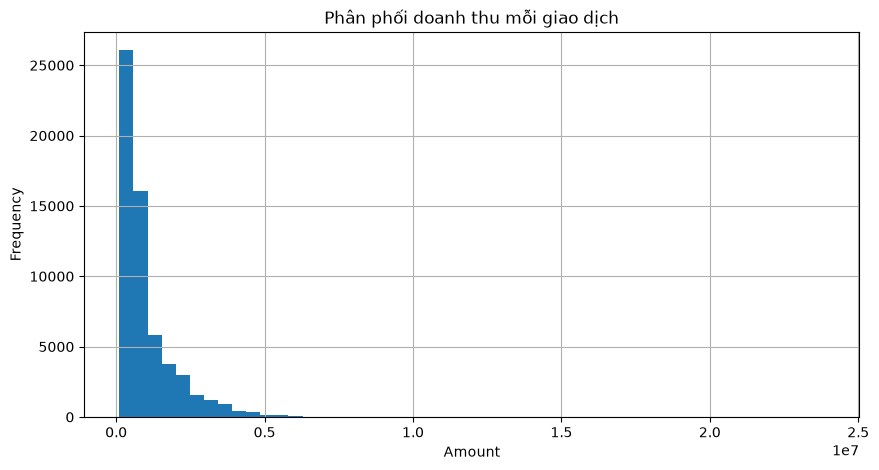

In [27]:
plt.figure(figsize=(10, 5))

plt.hist(
    df["amount"],
    bins=50
)

plt.title("Phân phối doanh thu mỗi giao dịch")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.grid(True)

plt.show()

### 7. Phân tích trạng thái giao dịch

Dataset có hai trạng thái:

- `HOAN_TAT`
- `HOAN_TRA`

Khi tính doanh thu thực tế, cần cân nhắc trạng thái giao dịch.

Một giao dịch hoàn trả không nên được xem như doanh thu bán hàng bình thường.

Trong bài lab này, chúng ta sẽ định nghĩa:

> **Doanh thu hợp lệ = tổng `amount` của các giao dịch `HOAN_TAT`.**

In [28]:
print(df["status"].value_counts())

print("\nTỷ lệ:")
print(df["status"].value_counts(normalize=True) * 100)

status
HOAN_TAT    57882
HOAN_TRA     2103
Name: count, dtype: int64

Tỷ lệ:
status
HOAN_TAT    96.494124
HOAN_TRA     3.505876
Name: proportion, dtype: float64


#### 8. Xây dựng dataset theo ngày

Dữ liệu ban đầu là dữ liệu transaction-level.

Ví dụ:

| transaction | customer | amount |
|---|---|---:|
| T001 | C001 | 500 |
| T002 | C002 | 800 |
| T003 | C001 | 300 |

Tuy nhiên mục tiêu của chúng ta là:

> Dự đoán tổng doanh thu của ngày tiếp theo.

Do đó cần chuyển từ:

**Transaction-level**

sang:

**Daily-level**

#### Target

Ta định nghĩa:

$$
Revenue_t = \sum Amount_i
$$

với các giao dịch `HOAN_TAT` xảy ra trong ngày $t$.

In [29]:
# Chỉ sử dụng giao dịch hoàn tất để tính doanh thu
completed = df[df["status"] == "HOAN_TAT"].copy()

# Tạo biến ngày
completed["date"] = completed["ts"].dt.date

# Tổng hợp theo ngày
daily = (
    completed
    .groupby("date")
    .agg(
        revenue=("amount", "sum"),
        orders=("transaction_id", "count"),
        customers=("customer_id", "nunique"),
        avg_order_value=("amount", "mean"),
        total_quantity=("quantity", "sum"),
        total_cost=("cost", "sum")
    )
    .reset_index()
)

daily["date"] = pd.to_datetime(daily["date"])

daily = daily.sort_values("date").reset_index(drop=True)

daily.head()

,date,revenue,orders,customers,avg_order_value,total_quantity,total_cost
0,2025-01-01,1.467567e+08,128,123,1.146537e+06,235.0,1.079619e+08
1,2025-01-02,2.148952e+08,186,177,1.155350e+06,353.0,1.559626e+08
2,2025-01-03,1.576461e+08,178,172,8.856521e+05,295.0,1.137069e+08
3,2025-01-04,2.008606e+08,181,174,1.109727e+06,321.0,1.442242e+08
4,2025-01-05,2.068831e+08,180,172,1.149351e+06,325.0,1.495968e+08


In [30]:
print("Số ngày:", len(daily))

print("\nKhoảng thời gian:")
print(daily["date"].min(), "->", daily["date"].max())

daily.describe()

Số ngày: 313

Khoảng thời gian:
2025-01-01 00:00:00 -> 2025-11-09 00:00:00


,date,revenue,orders,customers,avg_order_value,total_quantity,total_cost
count,313,3.130000e+02,313.000000,313.000000,3.130000e+02,313.000000,3.130000e+02
mean,2025-06-06 00:00:00,1.931492e+08,184.926518,176.591054,1.044505e+06,327.840256,1.393194e+08
min,2025-01-01 00:00:00,5.770885e+07,57.000000,54.000000,8.131065e+05,89.000000,4.297753e+07
25%,2025-03-20 00:00:00,1.795272e+08,181.000000,172.000000,9.707927e+05,314.000000,1.299281e+08
50%,2025-06-06 00:00:00,1.935051e+08,186.000000,177.000000,1.042452e+06,330.000000,1.396010e+08
75%,2025-08-23 00:00:00,2.059767e+08,190.000000,182.000000,1.109727e+06,342.000000,1.485565e+08
max,2025-11-09 00:00:00,2.634774e+08,212.000000,201.000000,1.394060e+06,385.000000,1.902613e+08
std,NaN,2.163251e+07,10.637577,10.460189,1.011906e+05,24.487701,1.551818e+07


### 10. Doanh thu theo ngày

Quan sát biến động doanh thu theo thời gian.

Hãy chú ý:

- Xu hướng tăng/giảm
- Các ngày có doanh thu bất thường
- Tính chu kỳ
- Các giai đoạn biến động mạnh

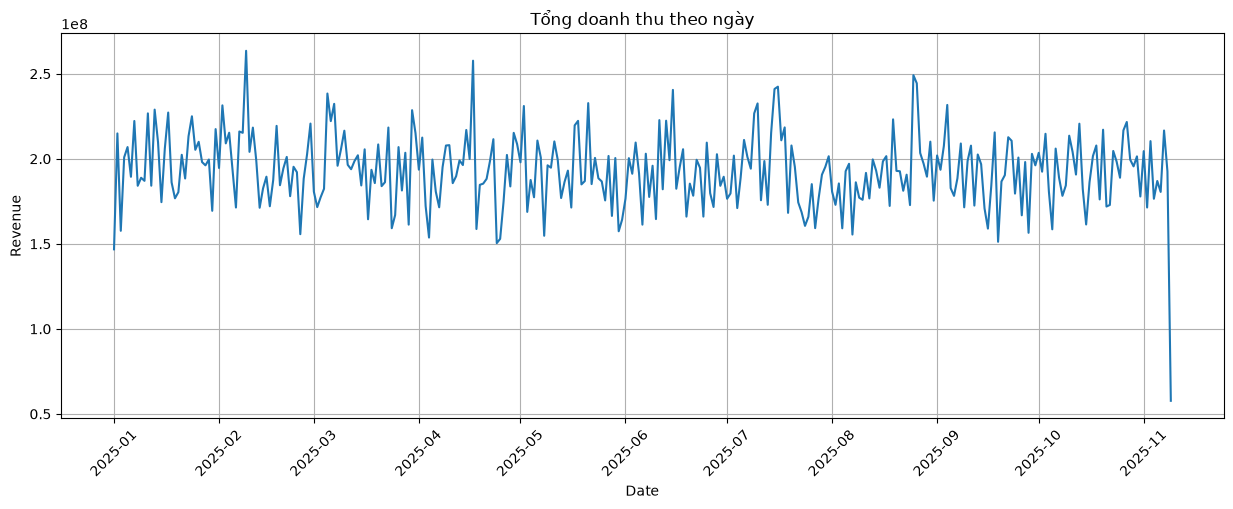

In [31]:
plt.figure(figsize=(15, 5))

plt.plot(
    daily["date"],
    daily["revenue"]
)

plt.title("Tổng doanh thu theo ngày")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### 11. Feature Engineering

Một trong những kỹ năng quan trọng khi xây dựng Machine Learning trên dữ liệu
thực tế là tạo ra các đặc trưng có ý nghĩa.

#### Nhóm 1: Time Features

Từ `date`, tạo:

- `day_of_week`
- `day_of_month`
- `month`
- `quarter`
- `week_of_year`
- `is_weekend`

Các biến này giúp mô hình nhận biết các pattern theo thời gian.

In [32]:
daily["day_of_week"] = daily["date"].dt.dayofweek
daily["day_of_month"] = daily["date"].dt.day
daily["month"] = daily["date"].dt.month
daily["quarter"] = daily["date"].dt.quarter
daily["week_of_year"] = daily["date"].dt.isocalendar().week.astype(int)

daily["is_weekend"] = (
    daily["day_of_week"] >= 5
).astype(int)

daily.head()

,date,revenue,orders,customers,avg_order_value,total_quantity,total_cost,day_of_week,day_of_month,month,quarter,week_of_year,is_weekend
0,2025-01-01,1.467567e+08,128,123,1.146537e+06,235.0,1.079619e+08,2,1,1,1,1,0
1,2025-01-02,2.148952e+08,186,177,1.155350e+06,353.0,1.559626e+08,3,2,1,1,1,0
2,2025-01-03,1.576461e+08,178,172,8.856521e+05,295.0,1.137069e+08,4,3,1,1,1,0
3,2025-01-04,2.008606e+08,181,174,1.109727e+06,321.0,1.442242e+08,5,4,1,1,1,1
4,2025-01-05,2.068831e+08,180,172,1.149351e+06,325.0,1.495968e+08,6,5,1,1,1,1


### 12. Lag Features

Doanh thu của ngày hôm nay thường có liên quan đến doanh thu của những ngày trước.

Ta tạo:

- `revenue_lag_1`: doanh thu ngày hôm trước
- `revenue_lag_2`: doanh thu 2 ngày trước
- `revenue_lag_7`: doanh thu 7 ngày trước

Ví dụ:

$$
RevenueLag_1(t) = Revenue(t-1)
$$

$$
RevenueLag_7(t) = Revenue(t-7)
$$

Đặc biệt `lag_7` có thể giúp mô hình phát hiện pattern theo tuần.

In [33]:
daily["revenue_lag_1"] = daily["revenue"].shift(1)
daily["revenue_lag_2"] = daily["revenue"].shift(2)
daily["revenue_lag_7"] = daily["revenue"].shift(7)

daily["orders_lag_1"] = daily["orders"].shift(1)
daily["orders_lag_7"] = daily["orders"].shift(7)

daily.head(10)

,date,revenue,orders,customers,avg_order_value,total_quantity,total_cost,day_of_week,day_of_month,month,quarter,week_of_year,is_weekend,revenue_lag_1,revenue_lag_2,revenue_lag_7,orders_lag_1,orders_lag_7
0,2025-01-01,1.467567e+08,128,123,1.146537e+06,235.0,1.079619e+08,2,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,2.148952e+08,186,177,1.155350e+06,353.0,1.559626e+08,3,2,1,1,1,0,1.467567e+08,NaN,NaN,128.0,NaN
2,2025-01-03,1.576461e+08,178,172,8.856521e+05,295.0,1.137069e+08,4,3,1,1,1,0,2.148952e+08,1.467567e+08,NaN,186.0,NaN
3,2025-01-04,2.008606e+08,181,174,1.109727e+06,321.0,1.442242e+08,5,4,1,1,1,1,1.576461e+08,2.148952e+08,NaN,178.0,NaN
4,2025-01-05,2.068831e+08,180,172,1.149351e+06,325.0,1.495968e+08,6,5,1,1,1,1,2.008606e+08,1.576461e+08,NaN,181.0,NaN
5,2025-01-06,1.894025e+08,186,183,1.018293e+06,327.0,1.350474e+08,0,6,1,1,2,0,2.068831e+08,2.008606e+08,NaN,180.0,NaN
6,2025-01-07,2.222103e+08,174,173,1.277070e+06,320.0,1.587250e+08,1,7,1,1,2,0,1.894025e+08,2.068831e+08,NaN,186.0,NaN
7,2025-01-08,1.841202e+08,182,172,1.011649e+06,314.0,1.319163e+08,2,8,1,1,2,0,2.222103e+08,1.894025e+08,1.467567e+08,174.0,128.0
8,2025-01-09,1.888255e+08,199,192,9.488720e+05,326.0,1.372254e+08,3,9,1,1,2,0,1.841202e+08,2.222103e+08,2.148952e+08,182.0,186.0
9,2025-01-10,1.870240e+08,185,181,1.010941e+06,330.0,1.371776e+08,4,10,1,1,2,0,1.888255e+08,1.841202e+08,1.576461e+08,199.0,178.0


### 13. Rolling Features

Ngoài doanh thu của từng ngày, chúng ta có thể sử dụng xu hướng gần đây.

Tạo:

- Trung bình doanh thu 3 ngày
- Trung bình doanh thu 7 ngày
- Độ lệch chuẩn doanh thu 7 ngày

Quan trọng:

> Rolling feature phải sử dụng `shift(1)` trước khi rolling.

Ví dụ:

$$
RollingMean_7(t)
=
Mean(Revenue_{t-7},...,Revenue_{t-1})
$$

Không được sử dụng `Revenue_t` để dự đoán chính `Revenue_t`.

In [34]:
daily["revenue_roll_mean_3"] = (
    daily["revenue"]
    .shift(1)
    .rolling(3)
    .mean()
)

daily["revenue_roll_mean_7"] = (
    daily["revenue"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily["revenue_roll_std_7"] = (
    daily["revenue"]
    .shift(1)
    .rolling(7)
    .std()
)

daily["orders_roll_mean_7"] = (
    daily["orders"]
    .shift(1)
    .rolling(7)
    .mean()
)

daily.head(12)

,date,revenue,orders,customers,avg_order_value,total_quantity,total_cost,day_of_week,day_of_month,month,quarter,week_of_year,is_weekend,revenue_lag_1,revenue_lag_2,revenue_lag_7,orders_lag_1,orders_lag_7,revenue_roll_mean_3,revenue_roll_mean_7,revenue_roll_std_7,orders_roll_mean_7
0,2025-01-01,1.467567e+08,128,123,1.146537e+06,235.0,1.079619e+08,2,1,1,1,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,2.148952e+08,186,177,1.155350e+06,353.0,1.559626e+08,3,2,1,1,1,0,1.467567e+08,NaN,NaN,128.0,NaN,NaN,NaN,NaN,NaN
2,2025-01-03,1.576461e+08,178,172,8.856521e+05,295.0,1.137069e+08,4,3,1,1,1,0,2.148952e+08,1.467567e+08,NaN,186.0,NaN,NaN,NaN,NaN,NaN
3,2025-01-04,2.008606e+08,181,174,1.109727e+06,321.0,1.442242e+08,5,4,1,1,1,1,1.576461e+08,2.148952e+08,NaN,178.0,NaN,1.730993e+08,NaN,NaN,NaN
4,2025-01-05,2.068831e+08,180,172,1.149351e+06,325.0,1.495968e+08,6,5,1,1,1,1,2.008606e+08,1.576461e+08,NaN,181.0,NaN,1.911339e+08,NaN,NaN,NaN
5,2025-01-06,1.894025e+08,186,183,1.018293e+06,327.0,1.350474e+08,0,6,1,1,2,0,2.068831e+08,2.008606e+08,NaN,180.0,NaN,1.884633e+08,NaN,NaN,NaN
6,2025-01-07,2.222103e+08,174,173,1.277070e+06,320.0,1.587250e+08,1,7,1,1,2,0,1.894025e+08,2.068831e+08,NaN,186.0,NaN,1.990487e+08,NaN,NaN,NaN
7,2025-01-08,1.841202e+08,182,172,1.011649e+06,314.0,1.319163e+08,2,8,1,1,2,0,2.222103e+08,1.894025e+08,1.467567e+08,174.0,128.0,2.061653e+08,1.912363e+08,2.877116e+07,173.285714
8,2025-01-09,1.888255e+08,199,192,9.488720e+05,326.0,1.372254e+08,3,9,1,1,2,0,1.841202e+08,2.222103e+08,2.148952e+08,182.0,186.0,1.985776e+08,1.965740e+08,2.175411e+07,181.000000
9,2025-01-10,1.870240e+08,185,181,1.010941e+06,330.0,1.371776e+08,4,10,1,1,2,0,1.888255e+08,1.841202e+08,1.576461e+08,199.0,178.0,1.983853e+08,1.928497e+08,2.027614e+07,182.857143


### 14. Xây dựng Target

Mục tiêu của bài toán là:

> Dự đoán doanh thu của ngày tiếp theo.

Do đó:

$$
Target_t = Revenue_{t+1}
$$

Ta tạo:

`target_revenue = revenue.shift(-1)`

Ví dụ:

| Date | Revenue | Target |
|---|---:|---:|
| 01/01 | 100 | 120 |
| 02/01 | 120 | 150 |
| 03/01 | 150 | 130 |

Ngày 01/01 sử dụng thông tin của ngày 01/01 để dự đoán doanh thu ngày 02/01.

In [35]:
daily["target_revenue"] = daily["revenue"].shift(-1)

display(
    daily[
        [
            "date",
            "revenue",
            "revenue_lag_1",
            "revenue_lag_7",
            "target_revenue"
        ]
    ].head(10)
)

,date,revenue,revenue_lag_1,revenue_lag_7,target_revenue
0,2025-01-01,1.467567e+08,NaN,NaN,2.148952e+08
1,2025-01-02,2.148952e+08,1.467567e+08,NaN,1.576461e+08
2,2025-01-03,1.576461e+08,2.148952e+08,NaN,2.008606e+08
3,2025-01-04,2.008606e+08,1.576461e+08,NaN,2.068831e+08
4,2025-01-05,2.068831e+08,2.008606e+08,NaN,1.894025e+08
5,2025-01-06,1.894025e+08,2.068831e+08,NaN,2.222103e+08
6,2025-01-07,2.222103e+08,1.894025e+08,NaN,1.841202e+08
7,2025-01-08,1.841202e+08,2.222103e+08,1.467567e+08,1.888255e+08
8,2025-01-09,1.888255e+08,1.841202e+08,2.148952e+08,1.870240e+08
9,2025-01-10,1.870240e+08,1.888255e+08,1.576461e+08,2.266881e+08


### 15. Kiểm tra Data Leakage

Đây là một trong những nội dung quan trọng nhất của bài lab.

Khi dự đoán doanh thu ngày $t+1$, feature chỉ được phép sử dụng thông tin
có sẵn **đến ngày $t$**.

Không được sử dụng:

- Doanh thu ngày $t+1$
- Số đơn hàng ngày $t+1$
- Thông tin giao dịch xảy ra sau thời điểm dự đoán

Nếu sử dụng những thông tin này, mô hình có thể đạt kết quả rất cao nhưng
không thể sử dụng trong thực tế.

#### Nguyên tắc

$$
Information\ Time \le Prediction\ Time
$$

### 16 Chuẩn bị dữ liệu cho Machine Learning

In [36]:
feature_cols = [
    "orders",
    "customers",
    "avg_order_value",
    "total_quantity",
    "total_cost",
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "week_of_year",
    "is_weekend",
    "revenue_lag_1",
    "revenue_lag_2",
    "revenue_lag_7",
    "orders_lag_1",
    "orders_lag_7",
    "revenue_roll_mean_3",
    "revenue_roll_mean_7",
    "revenue_roll_std_7",
    "orders_roll_mean_7"
]

ml_data = daily.dropna().copy()

X = ml_data[feature_cols]
y = ml_data["target_revenue"]

print("X:", X.shape)
print("y:", y.shape)

X: (305, 20)
y: (305,)


### 17. Train / Validation / Test Split

Không sử dụng random split.

Dữ liệu được chia theo thứ tự thời gian:

- 70% đầu tiên → Train
- 15% tiếp theo → Validation
- 15% cuối cùng → Test

Mục đích:

**Train**

Học pattern từ quá khứ.

**Validation**

Dùng để lựa chọn mô hình và hyperparameter.

**Test**

Đóng vai trò như dữ liệu tương lai hoàn toàn chưa được nhìn thấy.

In [37]:
n = len(ml_data)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train = ml_data.iloc[:train_end]
val = ml_data.iloc[train_end:val_end]
test = ml_data.iloc[val_end:]

X_train = train[feature_cols]
y_train = train["target_revenue"]

X_val = val[feature_cols]
y_val = val["target_revenue"]

X_test = test[feature_cols]
y_test = test["target_revenue"]

print("TRAIN")
print(train["date"].min(), "->", train["date"].max())

print("\nVALIDATION")
print(val["date"].min(), "->", val["date"].max())

print("\nTEST")
print(test["date"].min(), "->", test["date"].max())

TRAIN
2025-01-08 00:00:00 -> 2025-08-08 00:00:00

VALIDATION
2025-08-09 00:00:00 -> 2025-09-23 00:00:00

TEST
2025-09-24 00:00:00 -> 2025-11-08 00:00:00


### 18. Baseline Model

Trước khi sử dụng Machine Learning, cần xây dựng một baseline.

Baseline sử dụng chiến lược đơn giản:

> Dự đoán doanh thu ngày tiếp theo bằng doanh thu ngày hiện tại.

$$
\hat{Revenue}_{t+1} = Revenue_t
$$

Một Machine Learning model chỉ thực sự có ý nghĩa nếu nó tốt hơn baseline.

In [38]:
baseline_pred = test["revenue"].values

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        baseline_pred
    )
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("BASELINE")
print("-" * 30)
print(f"MAE  : {baseline_mae:,.2f}")
print(f"RMSE : {baseline_rmse:,.2f}")
print(f"R²   : {baseline_r2:.4f}")

BASELINE
------------------------------
MAE  : 24,917,944.45
RMSE : 32,568,549.82
R²   : -0.5844


### 19. Random Forest Regression

Tiếp theo sử dụng Random Forest.

Random Forest gồm nhiều Decision Tree và kết hợp kết quả của chúng.

Ưu điểm:

- Có khả năng học quan hệ phi tuyến
- Xử lý tốt nhiều loại feature
- Ít yêu cầu giả định về phân phối dữ liệu
- Có thể cung cấp Feature Importance

Đây là một mô hình phù hợp để xây dựng benchmark cho dataset doanh nghiệp.

In [39]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_val_pred = rf_model.predict(X_val)

rf_val_mae = mean_absolute_error(
    y_val,
    rf_val_pred
)

rf_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_val_pred
    )
)

rf_val_r2 = r2_score(
    y_val,
    rf_val_pred
)

print("RANDOM FOREST - VALIDATION")
print("-" * 40)
print(f"MAE  : {rf_val_mae:,.2f}")
print(f"RMSE : {rf_val_rmse:,.2f}")
print(f"R²   : {rf_val_r2:.4f}")

RANDOM FOREST - VALIDATION
----------------------------------------
MAE  : 16,097,416.78
RMSE : 21,096,887.13
R²   : -0.1546


### 20. Gradient Boosting Regression

Tiếp tục xây dựng Gradient Boosting.

Gradient Boosting xây dựng nhiều weak learners tuần tự,
trong đó mô hình sau cố gắng sửa lỗi của mô hình trước.

Mô hình này thường hoạt động tốt trên dữ liệu dạng bảng (tabular data).

In [40]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(
    X_train,
    y_train
)

gb_val_pred = gb_model.predict(X_val)

gb_val_mae = mean_absolute_error(
    y_val,
    gb_val_pred
)

gb_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        gb_val_pred
    )
)

gb_val_r2 = r2_score(
    y_val,
    gb_val_pred
)

print("GRADIENT BOOSTING - VALIDATION")
print("-" * 40)
print(f"MAE  : {gb_val_mae:,.2f}")
print(f"RMSE : {gb_val_rmse:,.2f}")
print(f"R²   : {gb_val_r2:.4f}")

GRADIENT BOOSTING - VALIDATION
----------------------------------------
MAE  : 18,276,768.83
RMSE : 24,675,284.72
R²   : -0.5795


In [41]:
comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        baseline_mae,
        rf_val_mae,
        gb_val_mae
    ],
    "RMSE": [
        baseline_rmse,
        rf_val_rmse,
        gb_val_rmse
    ],
    "R2": [
        baseline_r2,
        rf_val_r2,
        gb_val_r2
    ]
})

display(
    comparison.sort_values("RMSE")
)

,Model,MAE,RMSE,R2
1,Random Forest,1.609742e+07,2.109689e+07,-0.154612
2,Gradient Boosting,1.827677e+07,2.467528e+07,-0.579514
0,Baseline,2.491794e+07,3.256855e+07,-0.584410


### 22. Hyperparameter Tuning

Thay vì sử dụng các hyperparameter mặc định, chúng ta thử nhiều cấu hình.

Các hyperparameter quan trọng:

### Random Forest

- `n_estimators`
- `max_depth`
- `min_samples_leaf`

### Mục tiêu

Tìm cấu hình có RMSE thấp nhất trên Validation.

Lưu ý:

Không được sử dụng Test Set trong quá trình tuning.

In [42]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15],
    "min_samples_leaf": [1, 2, 5]
}

rf_tuning = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=3),
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best parameters:")
print(grid_search.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters:
{'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}


### 23 Đánh giá model tốt nhất trên validation

In [43]:
best_rf = grid_search.best_estimator_

best_val_pred = best_rf.predict(X_val)

best_val_mae = mean_absolute_error(
    y_val,
    best_val_pred
)

best_val_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        best_val_pred
    )
)

best_val_r2 = r2_score(
    y_val,
    best_val_pred
)

print("BEST RANDOM FOREST - VALIDATION")
print("-" * 45)
print(f"MAE  : {best_val_mae:,.2f}")
print(f"RMSE : {best_val_rmse:,.2f}")
print(f"R²   : {best_val_r2:.4f}")

BEST RANDOM FOREST - VALIDATION
---------------------------------------------
MAE  : 15,885,346.30
RMSE : 21,001,920.30
R²   : -0.1442


### 24. Huấn luyện Final Model

Sau khi lựa chọn được mô hình và hyperparameter bằng Train + Validation,
chúng ta có thể huấn luyện lại mô hình trên:

**Train + Validation**

Sau đó chỉ sử dụng Test Set một lần để đánh giá cuối cùng.

Đây là quy trình gần với Machine Learning thực tế:

In [44]:
train_val = pd.concat(
    [train, val],
    axis=0
)

X_train_val = train_val[feature_cols]
y_train_val = train_val["target_revenue"]

final_model = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    X_train_val,
    y_train_val
)

print("Final model training completed.")

Final model training completed.


### 25. Đánh giá cuối cùng trên Test Set

Test Set đại diện cho dữ liệu tương lai mà mô hình chưa từng sử dụng trong quá trình:

- Training
- Feature selection
- Model selection
- Hyperparameter tuning

Các metric:

- MAE
- RMSE
- R²

In [45]:
test_pred = final_model.predict(X_test)

test_mae = mean_absolute_error(
    y_test,
    test_pred
)

test_mse = mean_squared_error(
    y_test,
    test_pred
)

test_rmse = np.sqrt(test_mse)

test_r2 = r2_score(
    y_test,
    test_pred
)

print("FINAL TEST RESULTS")
print("=" * 40)
print(f"MAE  : {test_mae:,.2f}")
print(f"MSE  : {test_mse:,.2f}")
print(f"RMSE : {test_rmse:,.2f}")
print(f"R²   : {test_r2:.4f}")

FINAL TEST RESULTS
MAE  : 18,446,380.37
MSE  : 742,454,637,530,035.50
RMSE : 27,248,020.80
R²   : -0.1090


In [46]:
test_result = test[
    ["date", "target_revenue"]
].copy()

test_result["predicted_revenue"] = test_pred

test_result["error"] = (
    test_result["target_revenue"]
    - test_result["predicted_revenue"]
)

display(test_result.head(15))

,date,target_revenue,predicted_revenue,error
266,2025-09-24,2.007043e+08,1.946126e+08,6.091641e+06
267,2025-09-25,1.667637e+08,1.919989e+08,-2.523516e+07
268,2025-09-26,1.980738e+08,1.898123e+08,8.261488e+06
269,2025-09-27,1.564707e+08,1.972933e+08,-4.082260e+07
270,2025-09-28,2.028621e+08,1.945030e+08,8.359127e+06
271,2025-09-29,1.961402e+08,1.929210e+08,3.219140e+06
272,2025-09-30,2.035106e+08,1.900794e+08,1.343121e+07
273,2025-10-01,1.924118e+08,1.913206e+08,1.091168e+06
274,2025-10-02,2.146847e+08,1.879500e+08,2.673468e+07
275,2025-10-03,1.807595e+08,1.916821e+08,-1.092256e+07


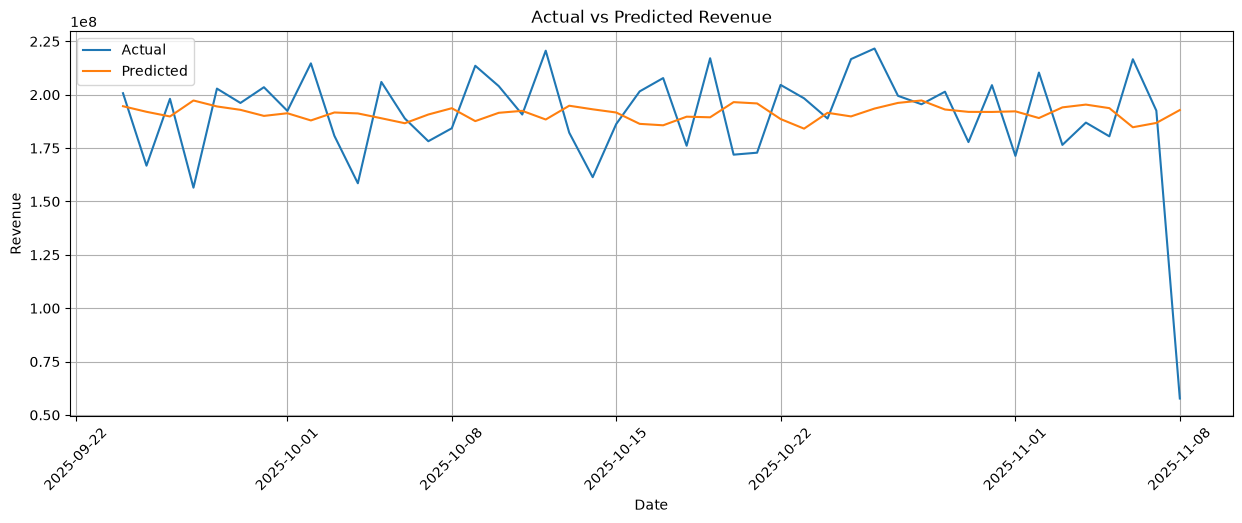

In [47]:
plt.figure(figsize=(15, 5))

plt.plot(
    test_result["date"],
    test_result["target_revenue"],
    label="Actual"
)

plt.plot(
    test_result["date"],
    test_result["predicted_revenue"],
    label="Predicted"
)

plt.title("Actual vs Predicted Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

### 27. Phân tích sai số

Không nên chỉ nhìn vào MAE/RMSE.

Hãy tìm những ngày mà mô hình dự đoán sai nhiều nhất.

Điều này giúp trả lời:

- Mô hình thường sai ở những ngày nào?
- Sai theo hướng dự đoán cao hay thấp?
- Có phải các ngày doanh thu đột biến khó dự đoán?

In [48]:
test_result["absolute_error"] = (
    test_result["error"].abs()
)

worst_days = (
    test_result
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

display(worst_days)

,date,target_revenue,predicted_revenue,error,absolute_error
311,2025-11-08,5.770885e+07,1.928174e+08,-1.351085e+08,1.351085e+08
269,2025-09-27,1.564707e+08,1.972933e+08,-4.082260e+07,4.082260e+07
276,2025-10-04,1.585214e+08,1.912387e+08,-3.271732e+07,3.271732e+07
284,2025-10-12,2.206190e+08,1.883910e+08,3.222806e+07,3.222806e+07
309,2025-11-06,2.166105e+08,1.847625e+08,3.184809e+07,3.184809e+07
286,2025-10-14,1.613719e+08,1.931640e+08,-3.179208e+07,3.179208e+07
298,2025-10-26,2.216303e+08,1.935172e+08,2.811314e+07,2.811314e+07
291,2025-10-19,2.170773e+08,1.894238e+08,2.765359e+07,2.765359e+07
297,2025-10-25,2.166821e+08,1.898403e+08,2.684187e+07,2.684187e+07
274,2025-10-02,2.146847e+08,1.879500e+08,2.673468e+07,2.673468e+07


### 28. Feature Importance

Random Forest cho phép ước lượng Feature Importance.

Mục tiêu:

> Xác định những yếu tố nào đóng góp nhiều nhất vào khả năng dự đoán doanh thu.

Điều này giúp chuyển kết quả Machine Learning thành insight kinh doanh.

In [49]:
importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": final_model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

display(importance)

,feature,importance
19,orders_roll_mean_7,0.107951
11,revenue_lag_1,0.087110
13,revenue_lag_7,0.074174
12,revenue_lag_2,0.068372
4,total_cost,0.068116
2,avg_order_value,0.067252
9,week_of_year,0.065759
3,total_quantity,0.062435
18,revenue_roll_std_7,0.052235
15,orders_lag_7,0.050679


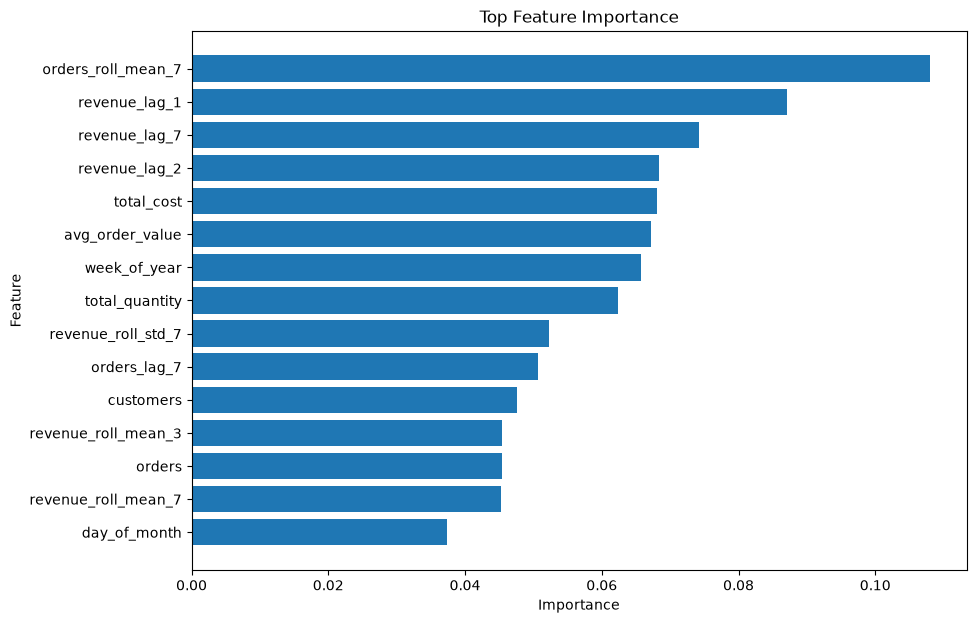

In [50]:
top_features = importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1]
)

plt.title("Top Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### 29. Dự đoán doanh thu cho ngày tiếp theo

Bây giờ mô hình đã được huấn luyện.

Giả sử dữ liệu hiện tại kết thúc ở ngày:

`T`

Ta muốn dự đoán:

`T + 1`

Feature sử dụng phải được xây dựng hoàn toàn từ dữ liệu đã biết tại thời điểm `T`.

Đây chính là cách mô hình có thể được sử dụng trong thực tế.

In [51]:
latest_features = daily.iloc[-1:][feature_cols]

next_day_prediction = final_model.predict(
    latest_features
)[0]

next_date = daily["date"].max() + pd.Timedelta(days=1)

print("Ngày cuối cùng trong dữ liệu:", daily["date"].max().date())
print("Ngày dự đoán:", next_date.date())
print(
    f"Doanh thu dự đoán: "
    f"{next_day_prediction:,.0f}"
)

Ngày cuối cùng trong dữ liệu: 2025-11-09
Ngày dự đoán: 2025-11-10
Doanh thu dự đoán: 189,128,475


### 30. Tổng kết

Trong bài lab này, chúng ta đã xây dựng một Machine Learning pipeline
trên dữ liệu giao dịch doanh nghiệp.

### Các kỹ năng đã thực hành

#### Data Understanding

- Đọc dữ liệu
- Kiểm tra schema
- Kiểm tra missing values
- Kiểm tra duplicate
- Phân tích categorical variables

#### Data Transformation

Chuyển:

**Transaction-level**

thành:

**Daily-level**

#### Feature Engineering

Đã xây dựng:

- Time features
- Lag features
- Rolling features
- Aggregated transaction features

#### Machine Learning

Đã thử:

- Baseline
- Random Forest
- Gradient Boosting

#### Model Selection

Sử dụng:

- Validation Set
- TimeSeriesSplit
- Grid Search

#### Evaluation

Sử dụng:

- MAE
- MSE
- RMSE
- R²

#### Model Interpretation

Sử dụng:

- Feature Importance
- Error Analysis

---

### Insight quan trọng

Một mô hình Machine Learning tốt không chỉ phụ thuộc vào thuật toán.

Quy trình quan trọng hơn:

$$
Data
\rightarrow
Feature Engineering
\rightarrow
Leakage Prevention
\rightarrow
Validation
\rightarrow
Model
\rightarrow
Evaluation
\rightarrow
Business Insight
$$

Đặc biệt đối với dữ liệu có yếu tố thời gian:

> **Không được sử dụng thông tin của tương lai để dự đoán quá khứ.**

Đây là một trong những nguyên tắc quan trọng nhất khi xây dựng
Machine Learning pipeline cho dữ liệu thực tế.

### 31. BÀI TẬP MỞ RỘNG

#### Bài tập 1 — Thêm đặc trưng

Bổ sung:

- Doanh thu trung bình 14 ngày
- Doanh thu lớn nhất 7 ngày
- Doanh thu nhỏ nhất 7 ngày
- Số đơn hàng trung bình 14 ngày
- Tăng trưởng doanh thu so với ngày hôm trước

Ví dụ:

$$
Growth_t =
\frac{Revenue_t-Revenue_{t-1}}
{Revenue_{t-1}}
$$

Đánh giá xem các feature mới có cải thiện mô hình hay không.

---

#### Bài tập 2 — Feature Engineering theo chi nhánh

Tạo các đặc trưng:

- Doanh thu Hà Nội
- Doanh thu Hải Phòng
- Doanh thu TP HCM
- Doanh thu Đà Nẵng
- Doanh thu Cần Thơ

Sau đó sử dụng các feature này để dự đoán tổng doanh thu ngày tiếp theo.

---

#### Bài tập 3 — Feature Engineering theo Channel

Tạo:

- Online revenue
- Store revenue
- Online orders
- Store orders

Kiểm tra xem kênh nào đóng góp nhiều hơn vào khả năng dự đoán.

---

#### Bài tập 4 — Feature Engineering theo Category

Tạo doanh thu theo từng category:

- Thời trang
- Thực phẩm
- Mỹ phẩm
- Điện tử
- Sách
- Gia dụng

Sau đó huấn luyện lại mô hình.

---

#### Bài tập 5 — So sánh mô hình

So sánh:

- Baseline
- Random Forest
- Gradient Boosting

Sử dụng:

- MAE
- RMSE
- R²

Trả lời:

> Mô hình nào tốt nhất và tại sao?

---

#### Bài tập 6 — Phân tích Data Leakage

Tạo một phiên bản mô hình cố tình sử dụng:

`revenue` của chính ngày cần dự đoán.

So sánh kết quả với mô hình đúng.

Giải thích:

> Tại sao mô hình bị Data Leakage có thể cho kết quả rất tốt nhưng
> không thể triển khai thực tế?

---

#### Bài tập 7 — Business Analysis

Dựa trên kết quả Feature Importance, hãy trả lời:

1. Những yếu tố nào ảnh hưởng mạnh nhất đến doanh thu?
2. Doanh thu có phụ thuộc vào số lượng đơn hàng không?
3. Doanh thu có pattern theo ngày trong tuần không?
4. Doanh thu có pattern theo tháng không?
5. Những ngày nào mô hình dự đoán sai nhiều nhất?
6. Doanh nghiệp có thể sử dụng mô hình này vào hoạt động nào?

---

#### Bài tập 8 — Đề xuất cải thiện

Đề xuất ít nhất 5 cách để cải thiện mô hình.

Ví dụ:

- Bổ sung dữ liệu khuyến mãi
- Bổ sung ngày lễ
- Bổ sung thời tiết
- Bổ sung giá sản phẩm
- Bổ sung marketing campaign
- Bổ sung tồn kho
- Sử dụng XGBoost/LightGBM
- Sử dụng mô hình Deep Learning cho Time Series